# 3-D Phase Surfaces — the Showcase Notebook

Two classic thermodynamic surfaces, every point computed by the `vle-thermo` Rust engine:

1. The **phase-envelope dome** of methane/ethane — the P–T saturation boundary at each composition, stacked into a 3-D dome, with the **critical locus** riding the ridge between the two pure critical points. Traced by the Michelsen continuation solver, which walks *through* each mixture's critical point.
2. The **P–x–y "sail"** of methanol/water — the bubble and dew surfaces vs temperature from the γ-φ (van Laar) path, using the research paper's Table 4.5 parameters.

The surface points are **pre-computed and stored in `notebooks/data/*.csv`** (committed to the repo), so this notebook renders instantly without re-running the thermodynamics. The full generation code is included below behind a `REGENERATE` switch.

## Setup (optional)

The cell below is **commented out by default**. Uncomment it to pull the latest `vle-thermo` from PyPI.

In [1]:
# Optional: pull the latest vle-thermo from PyPI.
# Uncomment if you want the newest released version instead of
# whatever is currently in your kernel. On the hosted hub this
# install is ephemeral — it vanishes when your session is culled.
# %pip install --upgrade vle-thermo

## Context

A binary mixture's saturation boundary is a *loop* in the P–T plane at each fixed composition — bubble branch and dew branch meeting at the mixture critical point (see [Chapter II](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md) and the [Chapter IV validation](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-4-validation.md)). Sweep the composition and those loops sweep out a **dome** whose ridge is the critical locus. The thesis's differential stepping could not cross the critical point; the modern engine's continuation solver (`trace_envelope_py`, Michelsen (24)) passes through it smoothly, which is what makes this surface drawable at all.

For a *sub*-critical polar system, the natural 3-D object is instead the P–x–y **sail**: the bubble surface $P(T, x_1)$ and dew surface $P(T, y_1)$, joined at the pure-component edges.

## Load the pre-computed surfaces

Data files (small CSVs, committed):
- `data/phase_dome_ch4_c2h6.csv` — (z₁, T, P) envelope points, 17 compositions × ~70 points
- `data/critical_locus_ch4_c2h6.csv` — (z₁, Tc, Pc) critical locus
- `data/pxy_sail_meoh_h2o.csv` — (T, x₁, y₁, P) bubble/dew points, 9 isotherms × 25 compositions

In [2]:
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
%matplotlib inline

def load(name):
    with (Path('data') / name).open() as fh:
        rows = list(csv.reader(fh))
    header, body = rows[0], np.array(rows[1:], dtype=float)
    return {h: body[:, i] for i, h in enumerate(header)}

dome = load('phase_dome_ch4_c2h6.csv')
crit = load('critical_locus_ch4_c2h6.csv')
sail = load('pxy_sail_meoh_h2o.csv')
print(f"dome: {len(dome['z1'])} pts   critical locus: {len(crit['z1'])} pts   sail: {len(sail['T_K'])} pts")

dome: 1187 pts   critical locus: 17 pts   sail: 225 pts


## Surface 1 — the phase-envelope dome (methane/ethane, PR)

Each colored curve is one composition's full phase envelope; the cyan ridge is the critical locus connecting pure ethane's critical point (305.3 K, 4.87 MPa) toward pure methane's (190.6 K, 4.60 MPa). Everything under the dome is two-phase.

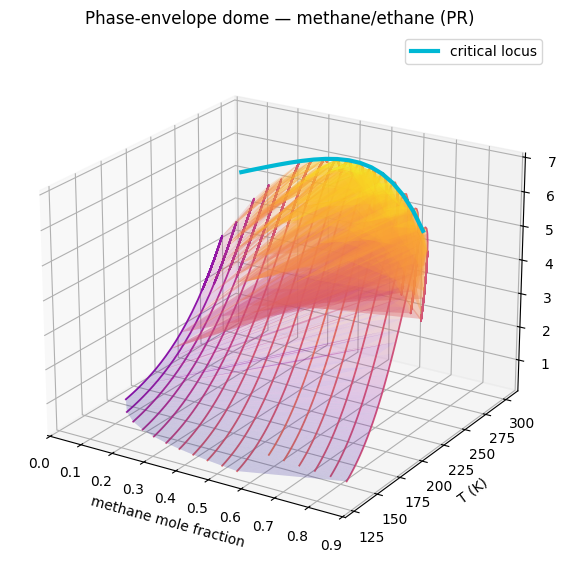

In [3]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')
z1, t, p = dome['z1'], dome['T_K'], dome['P_kPa']
norm = plt.Normalize(p.min(), p.max())
for z_val in np.unique(z1):
    m = z1 == z_val
    ax.plot(z1[m], t[m], p[m] / 1000.0, lw=1.3,
            color=cm.plasma(norm(p[m].mean())), alpha=0.95)
ax.plot_trisurf(z1, t, p / 1000.0, cmap='plasma', alpha=0.2, linewidth=0)
order = np.argsort(crit['z1'])
ax.plot(crit['z1'][order], crit['Tc_K'][order], crit['Pc_kPa'][order] / 1000.0,
        color='#00b8d4', lw=3, zorder=10, label='critical locus')
ax.set_xlabel('methane mole fraction')
ax.set_ylabel('T (K)')
ax.set_zlabel('P (MPa)')
ax.set_title('Phase-envelope dome — methane/ethane (PR)')
ax.view_init(elev=22, azim=-58)
ax.legend()
plt.show()

In [4]:
# Sanity pins: the critical locus must sit between the pure critical
# temperatures, and the dome's maximum pressure must exceed both pure
# critical pressures (the classic mixture Pc maximum).
assert crit['Tc_K'].min() > 190.5 and crit['Tc_K'].max() < 305.4
assert p.max() / 1000.0 > 4.9, 'dome should rise above both pure Pc values'
print('dome sanity checks pass')

dome sanity checks pass


## Surface 2 — the P–x–y sail (methanol/water, van Laar γ-φ)

The **bubble surface** (viridis, over the liquid composition $x_1$) and **dew surface** (magma, over the vapor composition $y_1$) share the same pressures — each bubble point's vapor lands on the dew surface. The gap between them at fixed (T, P) is the two-phase region; the surfaces close at the pure edges.

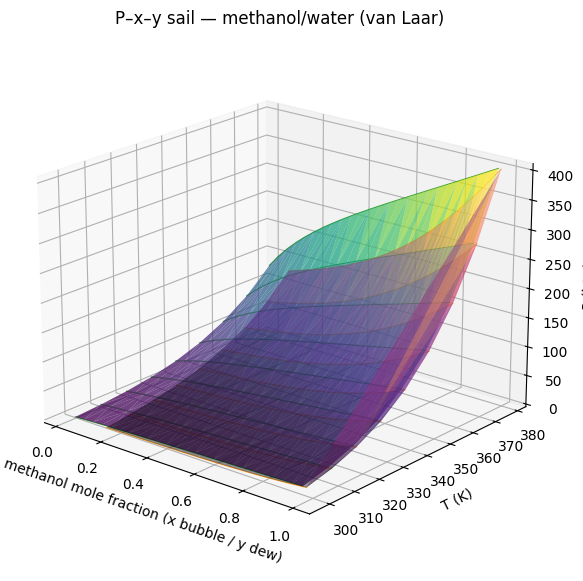

In [5]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(projection='3d')
ts, x1, y1, ps = sail['T_K'], sail['x1'], sail['y1'], sail['P_kPa']
ax.plot_trisurf(x1, ts, ps, cmap='viridis', alpha=0.75, linewidth=0)
ax.plot_trisurf(y1, ts, ps, cmap='magma', alpha=0.45, linewidth=0)
for t_val in np.unique(ts):
    m = ts == t_val
    ax.plot(x1[m], ts[m], ps[m], color='green', lw=0.8, alpha=0.8)
    ax.plot(y1[m], ts[m], ps[m], color='darkorange', lw=0.8, alpha=0.8)
ax.set_xlabel('methanol mole fraction (x bubble / y dew)')
ax.set_ylabel('T (K)')
ax.set_zlabel('P (kPa)')
ax.set_title('P–x–y sail — methanol/water (van Laar)')
ax.view_init(elev=20, azim=-50)
plt.show()

In [6]:
# Sanity pins: at every isotherm the bubble pressure rises with the
# methanol (more volatile) fraction, and y1 >= x1 throughout.
for t_val in np.unique(ts):
    m = ts == t_val
    assert np.all(np.diff(ps[m]) > 0), f'P(x1) not monotone at T={t_val}'
    assert np.all(y1[m] >= x1[m] - 1e-9), f'y1 < x1 at T={t_val}'
print('sail sanity checks pass')

sail sanity checks pass


## Regenerating the data (optional)

The cell below contains the **complete generation code** — the same logic as `scripts/generate_3d_surface_data.py`. It is guarded by `REGENERATE = False` so the notebook renders from the committed CSVs by default; flip the switch to recompute every point with the live engine (a couple of minutes). The dome traces 17 phase envelopes with `trace_envelope_py` + 17 critical points with `critical_point_py`; the sail solves 225 γ-φ bubble points with `bubble_pressure_py`.

In [7]:
REGENERATE = False  # flip to True to recompute the CSVs with the live engine

if REGENERATE:
    import vle._engine as e

    # ---- Surface 1: methane/ethane dome + critical locus (PR) ----
    tcs, pcs, om = [190.564, 305.32], [4599.0, 4872.0], [0.0115, 0.0995]
    env_rows, crit_rows = [], []
    for z1v in [round(0.05 * k, 2) for k in range(1, 18)]:  # 0.05 .. 0.85
        z = [z1v, 1 - z1v]
        pts = None
        for p_start in ([200.0, 500.0, 1000.0] if z1v < 0.6 else [500.0, 1000.0, 1500.0]):
            try:
                pts = e.trace_envelope_py(e.CubicEos.PR1976, tcs, pcs, om, z,
                                          p_start=p_start, max_points=70)
                break
            except (RuntimeError, ValueError):
                continue
        if pts is None:
            continue
        env_rows += [(z1v, tt, pp) for (tt, pp) in pts]
        tc_i, pc_i, _ = e.critical_point_py(
            e.CubicEos.PR1976, tcs, pcs, om, z,
            t_init=z1v * tcs[0] + (1 - z1v) * tcs[1])
        crit_rows.append((z1v, tc_i, pc_i))

    # ---- Surface 2: methanol/water P-x-y sail (van Laar) ----
    tcs2, pcs2, om2 = [512.6, 647.1], [8097.0, 22064.0], [0.564, 0.344]
    psat2 = [[7.493, 3603.0, -34.29], [6.240, 3803.0, -46.00]]
    aij2 = [[0.0, 0.5853], [0.3458, 0.0]]  # Table 4.5
    sail_rows = []
    for tv in [298.0 + 10.0 * k for k in range(9)]:
        for x1v in [round(0.02 + 0.04 * i, 2) for i in range(25)]:
            pv, yv, _ = e.bubble_pressure_py(
                tcs2, pcs2, om2, [x1v, 1 - x1v], tv,
                vapor_kind='ideal', liquid_kind='activity',
                liquid_activity=e.ActivityModel.VanLaar,
                aij=aij2, psat_coeffs=psat2, tol=1e-10)
            sail_rows.append((tv, x1v, yv[0], pv))

    # ---- Write the CSVs the plotting cells read ----
    def write(name, header, rows):
        with (Path('data') / name).open('w', newline='') as fh:
            w = csv.writer(fh)
            w.writerow(header)
            w.writerows([[f'{v:.6g}' for v in r] for r in rows])
        print(f'wrote data/{name} ({len(rows)} rows)')

    write('phase_dome_ch4_c2h6.csv', ['z1', 'T_K', 'P_kPa'], env_rows)
    write('critical_locus_ch4_c2h6.csv', ['z1', 'Tc_K', 'Pc_kPa'], crit_rows)
    write('pxy_sail_meoh_h2o.csv', ['T_K', 'x1', 'y1', 'P_kPa'], sail_rows)
else:
    print('using the committed CSVs (set REGENERATE = True to recompute)')

using the committed CSVs (set REGENERATE = True to recompute)


### Interactive version (optional)

For a rotate/zoom version when running live, uncomment the Plotly cell below (`pip install plotly` if needed). Note GitHub does *not* render Plotly output in saved notebooks — the matplotlib figures above are the always-visible renders.

In [8]:
# %pip install plotly
# import plotly.graph_objects as go
# fig = go.Figure()
# for z_val in np.unique(dome['z1']):
#     m = dome['z1'] == z_val
#     fig.add_trace(go.Scatter3d(x=dome['z1'][m], y=dome['T_K'][m],
#         z=dome['P_kPa'][m] / 1000.0, mode='lines', showlegend=False))
# fig.add_trace(go.Scatter3d(x=crit['z1'], y=crit['Tc_K'],
#     z=crit['Pc_kPa'] / 1000.0, mode='lines+markers', name='critical locus',
#     line=dict(color='cyan', width=6)))
# fig.update_layout(scene=dict(xaxis_title='z1 methane',
#     yaxis_title='T (K)', zaxis_title='P (MPa)'), template='plotly_dark')
# fig.show()

## Exercise 1 — a different pair

Regenerate the dome for **ethane/propane** (Tc = 305.32/369.83 K, Pc = 4872/4248 kPa, ω = 0.0995/0.1523) using the `REGENERATE` code above as a template. How does the critical locus differ from methane/ethane's? (Hint: this pair is closer-boiling.)

In [9]:
# TODO: adapt the dome-generation loop to ethane/propane and plot it
# with the same plotting code as Surface 1.


<details><summary>Solution sketch</summary>

Replace `tcs, pcs, om` with the ethane/propane constants and rerun the loop (seeds of 200–500 kPa work across the whole sweep — the pair is closer-boiling, so no methane-like steep side). The critical locus hugs the straight line between the pure critical points much more closely, and the dome's pressure maximum barely exceeds the pure-component Pc values — near-ideal mixtures make gentle domes.
</details>

## Exercise 2 — slice the sail

Extract the 338 K isotherm from the sail data and plot the classic 2-D P–x–y diagram (P vs x₁ and P vs y₁ on one axes). Confirm it matches the corresponding slice of the 3-D figure.

In [10]:
# TODO: mask sail['T_K'] == 338.0 and plot P vs x1 and P vs y1.


<details><summary>Solution</summary>

```python
m = sail['T_K'] == 338.0
plt.plot(sail['x1'][m], sail['P_kPa'][m], label='bubble P(x1)')
plt.plot(sail['y1'][m], sail['P_kPa'][m], label='dew P(y1)')
plt.xlabel('methanol mole fraction'); plt.ylabel('P (kPa)')
plt.title('methanol/water at 338 K'); plt.legend(); plt.grid(True)
plt.show()
```
</details>

## References

- (24) Michelsen (1980) — phase-envelope continuation; engine: `engine/src/flash/envelope.rs`.
- (16) Heidemann & Khalil (1980) — the critical locus; engine: `engine/src/flash/critical.rs`.
- Bubble/dew γ-φ path: [notebook 04](04_bubble_dew_point.ipynb) and `engine/src/flash/bubble.rs`.
- Data generation: `scripts/generate_3d_surface_data.py`; hero image: `scripts/render_3d_hero.py`.
- Research paper: [Chapter II](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-2-vle-theory.md), [Chapter IV](https://github.com/miguelju/vle/blob/main/docs/en/research-paper/chapter-4-validation.md).
